# Translating a circuit into matchgates

<table class="nt-notebook-buttons" align="center">
  <td>
    <a target="_blank" href="https://MatchCake.github.io/MajoranaKaraoke/">Documentation</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/MatchCake/MajoranaKaraoke/blob/main/tutorials/translating_a_circuit.ipynb">Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/MatchCake/MajoranaKaraoke/blob/main/tutorials/translating_a_circuit.ipynb">View source on GitHub</a>
  </td>
  <td>
    <a href="https://github.com/MatchCake/MajoranaKaraoke/blob/main/tutorials/translating_a_circuit.ipynb?raw=true">Download notebook</a>
  </td>
</table>

A matchgate is a two-qubit gate acting on neighbouring wires as

$$
G(A, B) = \begin{pmatrix} A_{11} & 0 & 0 & A_{12} \\ 0 & B_{11} & B_{12} & 0 \\ 0 & B_{21} & B_{22} & 0 \\ A_{21} & 0 & 0 & A_{22} \end{pmatrix},
\qquad \det A = \det B .
$$

Through the Jordan–Wigner transformation, matchgates are free-fermion evolutions, so a circuit made of them is simulated
in polynomial time [1-3], here by MatchCake's `nif.qubit` device. Generic circuits are believed to be hard to simulate
classically: a statevector simulator stores $2^n$ amplitudes.

`majorana_karaoke` translates any unitary circuit into a matchgate circuit, its *karaoke* version, and simulates it on
`nif.qubit` through the `mk.qubit` device. An `Adjoint` operation, which `qml.adjoint` creates by default, is translated
into the inverse of the translation of its base. MatchCake operations and the state preparations that `nif.qubit`
executes, such as `BasisState` (extended with zeros to every wire), are kept as they are. Every other operation goes
through the first rule that applies:

1. **Rules by name.** `CNOT` takes its Mølmer–Sørensen form
   $\mathrm{CNOT}_{c,t} = e^{-i\pi/4}\, R_Y^{(c)}(-\tfrac{\pi}{2})\, R_X^{(c)}(-\tfrac{\pi}{2})\, R_X^{(t)}(-\tfrac{\pi}{2})\, \mathrm{XX}_{c,t}(\tfrac{\pi}{2})\, R_Y^{(c)}(\tfrac{\pi}{2})$,
   whose entangling part $\mathrm{XX}(\tfrac{\pi}{2}) = e^{-i\frac{\pi}{4} X \otimes X}$ is a matchgate. `GlobalPhase` and
   `Identity` are dropped. The operations a rule returns are translated in turn.
2. **Matchgates**, that is two-qubit gates that are matchgates for every value of their scalar parameters, such as
   `IsingXX`, `IsingYY`, `IsingXY` or `SingleExcitation`, become a `MatchgateOperation`. On
   distant wires, `fSWAP` gates carry the higher wire next to the lower one and back: the result is the fermionic
   version of the gate, which carries a Jordan–Wigner string $Z$ on the wires in between.
3. **Single-qubit gates.** A gate $G$ on the wire $w$ is dressed into the matchgate
   $M(G, G) = \mathrm{CNOT}_{w,w+1}\,(G \otimes I)\,\mathrm{CNOT}_{w,w+1}$ on $(w, w+1)$. On the last wire, it becomes
   $M(G, XGX) = \mathrm{CNOT}_{w,w-1}\,(I \otimes G)\,\mathrm{CNOT}_{w,w-1}$ on $(w-1, w)$. The dressed gate acts as $G$
   only when $G$ is diagonal.
4. **Anything else** is decomposed, and its decomposition is translated. An operation with a matrix but no
   decomposition is translated as a `QubitUnitary` of its matrix, with a warning.

The translation is therefore exact for circuits made of neighbouring matchgates and diagonal single-qubit gates. For any
other circuit, it gives a matchgate counterpart of the circuit, not the circuit itself. This notebook checks each of these
statements numerically.

[1] L. G. Valiant, *Quantum circuits that can be simulated classically in polynomial time*, SIAM J. Comput. **31**, 1229
(2002).

[2] B. M. Terhal and D. P. DiVincenzo, *Classical simulation of noninteracting-fermion quantum circuits*, Phys. Rev. A
**65**, 032325 (2002).

[3] R. Jozsa and A. Miyake, *Matchgates and classical simulation of quantum circuits*, Proc. R. Soc. A **464**, 3089
(2008).

## Setup

Install the package if needed, for example in Google Colab, by uncommenting the line below.

In [1]:
# @title Install dependencies {display-mode: "form"}

# !pip install git+https://github.com/MatchCake/MajoranaKaraoke

## Imports

We use PennyLane to write circuits, `default.qubit` as the statevector reference and `mk.qubit` (or equivalently
`majorana_karaoke.MajoranaKaraokeDevice`) to run their matchgate translation. A few helpers compare the results.

In [2]:
import time
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
from matchcake.operations import fSWAP
from pennylane.operation import Operator
from pennylane.typing import TensorLike

import majorana_karaoke as mk


def total_variation_distance(probs: TensorLike, other_probs: TensorLike) -> float:
    """
    Total variation distance between two probability distributions.

    :param probs: The first distribution.
    :param other_probs: The second distribution.
    :return: Half of the l1 distance between the two distributions, between 0 (identical) and 1 (disjoint).
    """
    return 0.5 * float(np.sum(np.abs(qml.math.to_numpy(probs) - qml.math.to_numpy(other_probs))))


def max_abs_difference(array: TensorLike, other_array: TensorLike) -> float:
    """
    Largest absolute difference between the entries of two arrays.

    :param array: The first array.
    :param other_array: The second array.
    :return: The largest absolute difference.
    """
    return float(np.max(np.abs(qml.math.to_numpy(array) - qml.math.to_numpy(other_array))))


def operations_matrix(operations: Sequence[Operator], wire_order: Sequence[int]) -> np.ndarray:
    """
    Unitary matrix of a sequence of operations applied one after the other.

    :param operations: The operations, in the order they are applied.
    :param wire_order: The wires of the matrix.
    :return: The matrix of the product of the operations.
    """
    return qml.math.to_numpy(qml.matrix(qml.tape.QuantumScript(operations), wire_order=wire_order))


def describe(operations: Sequence[Operator]) -> str:
    """
    Short description of a sequence of operations: their names and wires.

    :param operations: The operations to describe.
    :return: The comma-separated names and wires of the operations.
    """
    return ", ".join(f"{op.name}{op.wires.tolist()}" for op in operations)

## A first circuit

A Hadamard, an $R_X$, two CNOTs and an $R_Z$ on three qubits.

In [3]:
n_wires = 3
angles = np.array([0.3, 0.7])


def first_circuit(angles):
    qml.Hadamard(wires=0)
    qml.RX(angles[0], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RZ(angles[1], wires=2)
    qml.CNOT(wires=[1, 2])
    return qml.probs(wires=range(n_wires))


reference_qnode = qml.QNode(first_circuit, qml.device("default.qubit", wires=n_wires))
print(qml.draw(reference_qnode)(angles))

0: ──H────────╭●────┤ ╭Probs
1: ──RX(0.30)─╰X─╭●─┤ ├Probs
2: ──RZ(0.70)────╰X─┤ ╰Probs


`translate_to_matchgates` is a PennyLane transform. Applied to a QNode, it replaces every operation by its translation;
`level="user"` draws the circuit after the transform. Every gate becomes one or several `MatchgateOperation`s on
neighbouring wires.

In [4]:
karaoke_qnode = mk.translate_to_matchgates(reference_qnode)
print(qml.draw(karaoke_qnode, level="user", show_matrices=False)(angles))

0: ─╭MatchgateOperation(M0)─────────────────────────╭MatchgateOperation(M2) ···
1: ─╰MatchgateOperation(M0)─╭MatchgateOperation(M1)─╰MatchgateOperation(M2) ···
2: ─────────────────────────╰MatchgateOperation(M1)──────────────────────── ···

0: ··· ─╭MatchgateOperation(M3)─╭MatchgateOperation(M4)──────────────────────── ···
1: ··· ─╰MatchgateOperation(M3)─╰MatchgateOperation(M4)─╭MatchgateOperation(M4) ···
2: ··· ─────────────────────────────────────────────────╰MatchgateOperation(M4) ···

0: ··· ─╭MatchgateOperation(M5)──────────────────────────────────────────────── ···
1: ··· ─╰MatchgateOperation(M5)─╭MatchgateOperation(M6)─╭MatchgateOperation(M2) ···
2: ··· ─────────────────────────╰MatchgateOperation(M6)─╰MatchgateOperation(M2) ···

0: ··· ──────────────────────────────────────────────────────────────────────── ···
1: ··· ─╭MatchgateOperation(M3)─╭MatchgateOperation(M4)─╭MatchgateOperation(M4) ···
2: ··· ─╰MatchgateOperation(M3)─╰MatchgateOperation(M4)─╰MatchgateOperation(M4) ···



The `mk.qubit` device applies the same translation before simulating the circuit with `nif.qubit`. Its probabilities
match those of the translated circuit run on `default.qubit`, and differ from those of the original circuit, since the
Hadamard, the $R_X$ and the rotations of the Mølmer–Sørensen form are not diagonal.

In [5]:
mk_device = qml.device("mk.qubit", wires=n_wires)
print(f"{type(mk_device).__name__} registered as {mk_device.name!r}")
mk_qnode = qml.QNode(first_circuit, mk_device)

original_probs = qml.math.to_numpy(reference_qnode(angles))
translated_probs = qml.math.to_numpy(karaoke_qnode(angles))
mk_probs = qml.math.to_numpy(mk_qnode(angles))

print("state  original  translated (default.qubit)  mk.qubit")
for index in range(2**n_wires):
    print(
        f"|{index:0{n_wires}b}>   {original_probs[index]:.4f}    {translated_probs[index]:.4f}"
        f"                      {mk_probs[index]:.4f}"
    )
print(f"TVD(mk.qubit, translated) = {total_variation_distance(mk_probs, translated_probs):.1e}")
print(f"TVD(mk.qubit, original)   = {total_variation_distance(mk_probs, original_probs):.3f}")

MajoranaKaraokeDevice registered as 'mk.qubit'
state  original  translated (default.qubit)  mk.qubit
|000>   0.4888    0.3239                      0.3239
|001>   0.0000    0.0000                      0.0000
|010>   0.0000    0.0000                      0.0000
|011>   0.0112    0.1761                      0.1761
|100>   0.0112    0.0000                      0.0000
|101>   0.0000    0.1761                      0.1761
|110>   0.0000    0.3239                      0.3239
|111>   0.4888    0.0000                      0.0000
TVD(mk.qubit, translated) = 3.4e-16
TVD(mk.qubit, original)   = 0.665


Here $\mathrm{TVD}(p, q) = \frac{1}{2}\sum_x |p(x) - q(x)|$ is the total variation distance, between $0$ (identical
distributions) and $1$ (disjoint supports).

## One operation at a time

`MatchgateTranslator` holds the rules. Its `translate` method returns the operations replacing a single operation, given
the wires of the device.

In [6]:
translator = mk.MatchgateTranslator()
three_wires = [0, 1, 2]
for op in [
    qml.Hadamard(wires=0),
    qml.RZ(0.3, wires=2),
    qml.IsingXY(0.3, wires=[0, 1]),
    qml.IsingXX(0.3, wires=[0, 2]),
    qml.CNOT(wires=[0, 1]),
    qml.SWAP(wires=[1, 2]),
    qml.GlobalPhase(0.3),
]:
    translated_ops = translator.translate(op, wire_order=three_wires)
    summary = describe(translated_ops) if len(translated_ops) <= 5 else f"{len(translated_ops)} operations"
    summary = summary or "dropped"
    print(f"{op.name}{op.wires.tolist()} -> {summary}")
print(f"SWAP[1, 2] is decomposed into {describe(qml.SWAP(wires=[1, 2]).decomposition())}")

Hadamard[0] -> MatchgateOperation[0, 1]
RZ[2] -> MatchgateOperation[1, 2]
IsingXY[0, 1] -> MatchgateOperation[0, 1]
IsingXX[0, 2] -> fSWAP[1, 2], MatchgateOperation[0, 1], fSWAP[1, 2]
CNOT[0, 1] -> MatchgateOperation[0, 1], MatchgateOperation[0, 1], MatchgateOperation[0, 1], MatchgateOperation[1, 2], MatchgateOperation[0, 1]
SWAP[1, 2] -> 15 operations
GlobalPhase[] -> dropped
SWAP[1, 2] is decomposed into CNOT[1, 2], CNOT[2, 1], CNOT[1, 2]


The single-qubit gate on the last wire is dressed on $(1, 2)$, the distant `IsingXX` is surrounded by `fSWAP`s, the
CNOT becomes five matchgates, the SWAP, which is not a matchgate, is decomposed into three CNOTs of five matchgates
each, and the global phase is dropped.

The dressing of a single-qubit gate $G$ is $\mathrm{CNOT}\,(G \otimes I)\,\mathrm{CNOT}$, which equals $G \otimes I$
only for diagonal gates, and $\mathrm{CNOT}_{1,0}\,(I \otimes G)\,\mathrm{CNOT}_{1,0}$ on the last wire:

In [7]:
two_wires = [0, 1]
cnot = qml.matrix(qml.CNOT(wires=[0, 1]))
reversed_cnot = qml.matrix(qml.CNOT(wires=[1, 0]), wire_order=two_wires)
identity = np.eye(2)

for gate in [qml.Hadamard(wires=0), qml.RX(0.7, wires=0), qml.RZ(0.7, wires=0), qml.T(wires=0)]:
    dressed = operations_matrix(translator.translate(gate, wire_order=two_wires), two_wires)
    gate_matrix = qml.matrix(gate)
    print(
        f"{gate.name:8s} |M(G,G) - CNOT (G x I) CNOT| = "
        f"{max_abs_difference(dressed, cnot @ np.kron(gate_matrix, identity) @ cnot):.1e}"
        f"    |M(G,G) - G x I| = {max_abs_difference(dressed, np.kron(gate_matrix, identity)):.1e}"
    )

last_wire_gate = qml.Hadamard(wires=1)
dressed = operations_matrix(translator.translate(last_wire_gate, wire_order=two_wires), two_wires)
expected = reversed_cnot @ np.kron(identity, qml.matrix(last_wire_gate)) @ reversed_cnot
print(f"Hadamard on the last wire: |M(H,XHX) - CNOT_10 (I x H) CNOT_10| = {max_abs_difference(dressed, expected):.1e}")

Hadamard |M(G,G) - CNOT (G x I) CNOT| = 0.0e+00    |M(G,G) - G x I| = 7.1e-01
RX       |M(G,G) - CNOT (G x I) CNOT| = 0.0e+00    |M(G,G) - G x I| = 3.4e-01
RZ       |M(G,G) - CNOT (G x I) CNOT| = 0.0e+00    |M(G,G) - G x I| = 0.0e+00
T        |M(G,G) - CNOT (G x I) CNOT| = 0.0e+00    |M(G,G) - G x I| = 0.0e+00
Hadamard on the last wire: |M(H,XHX) - CNOT_10 (I x H) CNOT_10| = 0.0e+00


The Mølmer–Sørensen operations multiply to $e^{i\pi/4}\,\mathrm{CNOT}$. Their rotations are not diagonal, so once they
are dressed the translated CNOT is no longer a CNOT, even up to a global phase: $|\mathrm{Tr}(\mathrm{CNOT}^\dagger V)|/4$
would be $1$ if it were.

In [8]:
molmer_sorensen = mk.MatchgateTranslator.cnot_to_molmer_sorensen(qml.CNOT(wires=[0, 1]))
print(describe(molmer_sorensen))
molmer_sorensen_matrix = operations_matrix(molmer_sorensen, two_wires)
print(f"|MS - e^(i pi/4) CNOT| = {max_abs_difference(molmer_sorensen_matrix, np.exp(1j * np.pi / 4) * cnot):.1e}")

translated_cnot = operations_matrix(translator.translate(qml.CNOT(wires=[0, 1]), wire_order=two_wires), two_wires)
print(f"|Tr(CNOT^dagger V)| / 4 = {abs(np.trace(cnot.conj().T @ translated_cnot)) / 4:.3f}")

RY[0], IsingXX[0, 1], RX[0], RX[1], RY[0]
|MS - e^(i pi/4) CNOT| = 1.8e-16
|Tr(CNOT^dagger V)| / 4 = 0.500


A matchgate on distant wires is routed with `fSWAP`s. For `IsingXX` on $(0, 2)$, the result is
$e^{-i\frac{\theta}{2} X_0 Z_1 X_2}$, where $X_0 Z_1 X_2 = -i\gamma_1 \gamma_4$ is a bilinear in the Majorana operators of the modes $0$
and $2$, and not the qubit gate $e^{-i\frac{\theta}{2} X_0 X_2}$:

In [9]:
theta = 0.9
routed = operations_matrix(translator.translate(qml.IsingXX(theta, wires=[0, 2]), wire_order=three_wires), three_wires)
fermionic = qml.matrix(qml.PauliRot(theta, "XZX", wires=three_wires))
qubit = qml.matrix(qml.IsingXX(theta, wires=[0, 2]), wire_order=three_wires)
print(f"|routed - exp(-i theta/2 X0 Z1 X2)| = {max_abs_difference(routed, fermionic):.1e}")
print(f"|routed - IsingXX on (0, 2)|        = {max_abs_difference(routed, qubit):.3f}")

|routed - exp(-i theta/2 X0 Z1 X2)| = 4.4e-16
|routed - IsingXX on (0, 2)|        = 0.870


## Exact on the free-fermion subset

A circuit made of matchgates on neighbouring wires (`IsingXX`, `IsingXY`, `IsingYY`, `SingleExcitation`) and diagonal
single-qubit gates ($R_Z$, $S$, $T$, phase shifts), applied to a basis state, is translated exactly: `mk.qubit` gives the
same probabilities as `default.qubit` on the original circuit. Each operation is translated into a single operation.

In [10]:
n_wires = 6
rng = np.random.default_rng(42)
free_fermion_params = rng.uniform(0, 2 * np.pi, size=(3, n_wires, 4))


def free_fermion_circuit(params):
    qml.BasisState(np.array([1, 0, 1, 1, 0, 0]), wires=range(n_wires))
    for layer in params:
        for wire in range(0, n_wires - 1, 2):
            qml.IsingXX(layer[wire, 0], wires=[wire, wire + 1])
            qml.IsingXY(layer[wire, 1], wires=[wire, wire + 1])
        for wire in range(1, n_wires - 1, 2):
            qml.SingleExcitation(layer[wire, 2], wires=[wire, wire + 1])
            qml.IsingYY(layer[wire, 3], wires=[wire, wire + 1])
        for wire in range(n_wires):
            qml.RZ(layer[wire, 0], wires=wire)
            qml.PhaseShift(layer[wire, 1], wires=wire)
        qml.S(wires=0)
        qml.T(wires=n_wires - 1)
    return qml.probs(wires=range(n_wires))


free_fermion_reference = qml.QNode(free_fermion_circuit, qml.device("default.qubit", wires=n_wires))
free_fermion_mk = qml.QNode(free_fermion_circuit, qml.device("mk.qubit", wires=n_wires))

original_ops = qml.workflow.construct_batch(free_fermion_reference, level="top")(free_fermion_params)[0][0].operations
translated_ops = qml.workflow.construct_batch(free_fermion_mk, level="device")(free_fermion_params)[0][0].operations
print(f"{len(original_ops)} operations translated into {len(translated_ops)} operations")

reference_probs = free_fermion_reference(free_fermion_params)
karaoke_probs = free_fermion_mk(free_fermion_params)
print(f"max |p_mk.qubit - p_default.qubit| = {max_abs_difference(karaoke_probs, reference_probs):.1e}")

73 operations translated into 73 operations


max |p_mk.qubit - p_default.qubit| = 5.1e-16


## A generic circuit

An `AngleEmbedding` followed by two `StronglyEntanglingLayers` on four qubits uses $R_X$ gates, general rotations and
CNOTs between distant wires. The translation is a different circuit: `mk.qubit` still agrees with `default.qubit` running
the translated operations, but both are far from the original circuit.

In [11]:
n_wires = 4
rng = np.random.default_rng(0)
weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=n_wires)
features = rng.uniform(0, np.pi, size=n_wires)
weights = rng.uniform(0, 2 * np.pi, size=weights_shape)


def generic_circuit(features, weights):
    qml.AngleEmbedding(features, wires=range(n_wires))
    qml.StronglyEntanglingLayers(weights, wires=range(n_wires))
    return qml.probs(wires=range(n_wires))


generic_reference = qml.QNode(generic_circuit, qml.device("default.qubit", wires=n_wires))
generic_translated = mk.translate_to_matchgates(generic_reference)
generic_mk = qml.QNode(generic_circuit, qml.device("mk.qubit", wires=n_wires))

original_probs = generic_reference(features, weights)
translated_probs = generic_translated(features, weights)
mk_probs = generic_mk(features, weights)
print(f"max |p_mk.qubit - p_translated| = {max_abs_difference(mk_probs, translated_probs):.1e}")
print(f"TVD(mk.qubit, original)         = {total_variation_distance(mk_probs, original_probs):.3f}")

max |p_mk.qubit - p_translated| = 2.2e-16
TVD(mk.qubit, original)         = 0.541


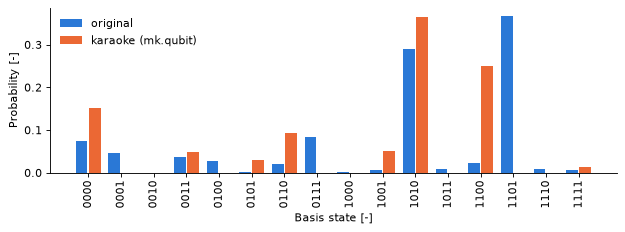

In [12]:
bitstrings = [f"{index:0{n_wires}b}" for index in range(2**n_wires)]
positions = np.arange(2**n_wires)
bar_width = 0.4

fig, ax = plt.subplots(figsize=(8, 3), dpi=80)
ax.bar(positions - bar_width / 2, qml.math.to_numpy(original_probs), bar_width * 0.9, color="#2a78d6", label="original")
karaoke_label = "karaoke (mk.qubit)"
ax.bar(positions + bar_width / 2, qml.math.to_numpy(mk_probs), bar_width * 0.9, color="#eb6834", label=karaoke_label)
ax.set_xticks(positions, bitstrings, rotation=90)
ax.set_xlabel("Basis state [-]")
ax.set_ylabel("Probability [-]")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Part of the difference is structural. Matchgates act separately on the even-parity states $\{|00\rangle, |11\rangle\}$ and
the odd-parity states $\{|01\rangle, |10\rangle\}$, so they conserve the parity of the number of $1$s: starting from
$|0000\rangle$, the karaoke version only reaches even-parity states, whereas the original circuit does not. Since the karaoke version puts no weight on odd-parity states, the total
variation distance is at least the odd-parity probability of the original circuit; the even-parity sector can differ
as well.

In [13]:
odd_parity_states = [index for index in range(2**n_wires) if bin(index).count("1") % 2 == 1]
original_odd_probability = qml.math.to_numpy(original_probs)[odd_parity_states].sum()
karaoke_odd_probability = qml.math.to_numpy(mk_probs)[odd_parity_states].sum()
print(f"odd-parity probability, original: {original_odd_probability:.3f}")
print(f"odd-parity probability, karaoke:  {karaoke_odd_probability:.1e}")

odd-parity probability, original: 0.541
odd-parity probability, karaoke:  8.0e-16


The distance is not specific to these parameters: over random features and weights, it stays large.

In [14]:
distances = []
for seed in range(10):
    seed_rng = np.random.default_rng(seed)
    seed_features = seed_rng.uniform(0, np.pi, size=n_wires)
    seed_weights = seed_rng.uniform(0, 2 * np.pi, size=weights_shape)
    seed_original_probs = generic_reference(seed_features, seed_weights)
    distances.append(total_variation_distance(generic_mk(seed_features, seed_weights), seed_original_probs))
summary = f"min {min(distances):.3f}, mean {np.mean(distances):.3f}, max {max(distances):.3f}"
print(f"TVD(mk.qubit, original) over {len(distances)} draws: {summary}")

TVD(mk.qubit, original) over 10 draws: min 0.541, mean 0.665, max 0.764


The karaoke version of a generic circuit is a different model, not an approximation with a controlled error. It is a
parametrized model that `nif.qubit` simulates efficiently, as the last section shows.

## Custom rules

`MatchgateTranslator(rules=...)` takes rules indexed by operation name; they take precedence over the default ones. By
default, a SWAP is decomposed into three CNOTs, each translated into five matchgates. The fermionic swap `fSWAP` is a
matchgate that differs from the SWAP only by a sign on $|11\rangle$:

In [15]:
print(np.real(qml.math.to_numpy(qml.matrix(fSWAP(wires=[0, 1])))))

[[ 1.  0.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  0. -1.]]


A rule replacing every SWAP by an `fSWAP` is therefore exact on states where the two wires are never both in
$|1\rangle$, such as a single excitation hopping along the chain. `fSWAP` acts on neighbouring wires only, so this rule is
meant for SWAPs between neighbours.

In [16]:
fswap_translator = mk.MatchgateTranslator(rules={"SWAP": lambda op: [fSWAP(wires=op.wires)]})
default_swap = translator.translate(qml.SWAP(wires=[1, 2]), wire_order=range(4))
custom_swap = fswap_translator.translate(qml.SWAP(wires=[1, 2]), wire_order=range(4))
print(f"default rules: SWAP[1, 2] -> {len(default_swap)} operations")
print(f"custom rule:   SWAP[1, 2] -> {describe(custom_swap)}")

default rules: SWAP[1, 2] -> 15 operations
custom rule:   SWAP[1, 2] -> fSWAP[1, 2]


The translator is passed to the device with the `translator` keyword. On a single-excitation circuit with SWAPs, the
custom rule gives the exact probabilities and the default rules do not.

In [17]:
n_wires = 4
rng = np.random.default_rng(1)
hopping_angles = rng.uniform(0, 2 * np.pi, size=(2, n_wires))


def single_excitation_circuit(angles):
    qml.BasisState(np.array([1, 0, 0, 0]), wires=range(n_wires))
    for layer in angles:
        for wire in range(n_wires - 1):
            qml.SingleExcitation(layer[wire], wires=[wire, wire + 1])
        qml.SWAP(wires=[1, 2])
        for wire in range(n_wires):
            qml.PhaseShift(layer[wire], wires=wire)
    return qml.probs(wires=range(n_wires))


hopping_reference = qml.QNode(single_excitation_circuit, qml.device("default.qubit", wires=n_wires))
hopping_default = qml.QNode(single_excitation_circuit, qml.device("mk.qubit", wires=n_wires))
hopping_custom = qml.QNode(
    single_excitation_circuit, qml.device("mk.qubit", wires=n_wires, translator=fswap_translator)
)

reference_probs = hopping_reference(hopping_angles)
for label, qnode in [("default rules", hopping_default), ("custom rule  ", hopping_custom)]:
    n_ops = len(qml.workflow.construct_batch(qnode, level="device")(hopping_angles)[0][0].operations)
    distance = total_variation_distance(qnode(hopping_angles), reference_probs)
    print(f"{label}: {n_ops:2d} operations, TVD to the original = {distance:.1e}")

default rules: 45 operations, TVD to the original = 9.0e-01
custom rule  : 17 operations, TVD to the original = 9.9e-16


## Scaling to 40 qubits

The state of `nif.qubit` is a $2n \times 2n$ single-particle transition matrix instead of $2^n$ amplitudes, so the
translated circuit runs on 40 qubits where a statevector would not fit in memory. We compute $\langle Z_0 \rangle$ of
the karaoke version of the generic circuit above on 40 qubits. This is the expectation value of the matchgate
counterpart; the original 40-qubit circuit is not computed here.

In [18]:
n_wires = 40
rng = np.random.default_rng(7)
large_weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=2, n_wires=n_wires)
large_features = rng.uniform(0, np.pi, size=n_wires)
large_weights = rng.uniform(0, 2 * np.pi, size=large_weights_shape)
large_device = qml.device("mk.qubit", wires=n_wires)


@qml.qnode(large_device)
def large_circuit(features, weights):
    qml.AngleEmbedding(features, wires=range(n_wires))
    qml.StronglyEntanglingLayers(weights, wires=range(n_wires))
    return qml.expval(qml.PauliZ(0))


start = time.perf_counter()
expectation_value = large_circuit(large_features, large_weights)
elapsed = time.perf_counter() - start

large_tape = qml.workflow.construct_batch(large_circuit, level="device")(large_features, large_weights)[0][0]
n_matchgates = len(large_tape.operations)
print(f"<Z_0> = {float(expectation_value):.4f} from {n_matchgates} matchgate operations in {elapsed:.1f} s")
print(f"nif.qubit state: transition matrix of shape {tuple(large_device.global_sptm.matrix().shape)}")
print(f"statevector: 2^{n_wires} complex128 amplitudes = {2**n_wires * 16 / 2**40:.0f} TiB")

<Z_0> = 0.2986 from 820 matchgate operations in 2.8 s
nif.qubit state: transition matrix of shape (80, 80)
statevector: 2^40 complex128 amplitudes = 16 TiB
